# Final_Exam_Kuan-Yu,HOU-ETU20240090

## Step 1: Descriptive Data Analysis (EDA)

In [3]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sn

In [4]:
df = pd.read_excel('QM501E_MSC_Dominos_Pizza_Sales.xlsx')
df.head(10)

,order_details_id,order_id,pizza_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name,PersonWhoDelivered,Distance,Housing,GenderOfTipper,Cash_Credit_Tip,Satisfaction_Rate,Recom_Rate
0,35497,15674,cali_ckn_l,4,2015-09-19,14:16:35,20.75,83.00,L,Chicken,"Chicken, Artichoke, Spinach, Garlic, Jalapeno ...",The California Chicken Pizza,Clara,2.2,Apartment,Female,Cash,0.205884,0.23
1,184,78,spicy_ital_l,3,2015-01-02,12:28:14,20.75,62.25,L,Supreme,"Capocollo, Tomatoes, Goat Cheese, Artichokes, ...",The Spicy Italian Pizza,Philip,1.1,House,Male,Cash,0.254965,0.29
2,18318,8040,thai_ckn_l,3,2015-05-15,14:13:27,20.75,62.25,L,Chicken,"Chicken, Pineapple, Tomatoes, Red Peppers, Tha...",The Thai Chicken Pizza,Pedro,1.9,House,Male,Credit,0.200632,0.24
3,37639,16619,prsc_argla_l,3,2015-10-08,12:19:53,20.75,62.25,L,Supreme,"Prosciutto di San Daniele, Arugula, Mozzarella...",The Prosciutto and Arugula Pizza,Thomas,0.7,House,Male,Cash,0.362180,0.39
4,38820,17112,bbq_ckn_l,3,2015-10-17,12:56:31,20.75,62.25,L,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",The Barbecue Chicken Pizza,Thomas,0.4,Hotel,Male,Cash,0.448598,0.52
5,35628,15728,ital_cpcllo_l,3,2015-09-20,12:30:44,20.50,61.50,L,Classic,"Capocollo, Red Peppers, Tomatoes, Goat Cheese,...",The Italian Capocollo Pizza,Thomas,2.3,Business,Male,Cash,0.283689,0.31
6,41559,18286,five_cheese_l,3,2015-11-08,13:13:56,18.50,55.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza,Clara,0.5,Apartment,Male,Credit,0.607977,0.73
7,12415,5452,the_greek_xl,2,2015-04-02,12:58:32,25.50,51.00,XL,Classic,"Kalamata Olives, Feta Cheese, Tomatoes, Garlic...",The Greek Pizza,Thomas,2.3,Apartment,Male,Credit,0.588382,0.70
8,15424,6762,the_greek_xl,2,2015-04-24,13:10:26,25.50,51.00,XL,Classic,"Kalamata Olives, Feta Cheese, Tomatoes, Garlic...",The Greek Pizza,Philip,2.1,Apartment,Male,Credit,0.037654,0.04
9,21608,9483,the_greek_xl,2,2015-06-08,18:03:51,25.50,51.00,XL,Classic,"Kalamata Olives, Feta Cheese, Tomatoes, Garlic...",The Greek Pizza,Clara,2.1,House,Female,Credit,0.642191,0.69


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   order_details_id    48620 non-null  int64         
 1   order_id            48620 non-null  int64         
 2   pizza_id            48620 non-null  object        
 3   quantity            48620 non-null  int64         
 4   order_date          48620 non-null  datetime64[ns]
 5   order_time          48620 non-null  object        
 6   unit_price          48620 non-null  float64       
 7   total_price         48620 non-null  float64       
 8   pizza_size          48620 non-null  object        
 9   pizza_category      48620 non-null  object        
 10  pizza_ingredients   48620 non-null  object        
 11  pizza_name          48620 non-null  object        
 12  PersonWhoDelivered  48619 non-null  object        
 13  Distance            48192 non-null  float64   

In [6]:
df.shape

(48620, 19)

In [7]:
df.columns

Index(['order_details_id', 'order_id', 'pizza_id', 'quantity', 'order_date',
       'order_time', 'unit_price', 'total_price', 'pizza_size',
       'pizza_category', 'pizza_ingredients', 'pizza_name',
       'PersonWhoDelivered', 'Distance', 'Housing', 'GenderOfTipper',
       'Cash_Credit_Tip', 'Satisfaction_Rate', 'Recom_Rate'],
      dtype='object')

### 1.1 Data Preprocessing

In [9]:
# to convert date column
df.order_date = pd.to_datetime(df.order_date)
df["order_date"]

0       2015-09-19
1       2015-01-02
2       2015-05-15
3       2015-10-08
4       2015-10-17
           ...    
48615   2015-12-29
48616   2015-12-29
48617   2015-12-31
48618   2015-12-31
48619   2015-12-31
Name: order_date, Length: 48620, dtype: datetime64[ns]

In [10]:
duplicate_rows = df[df.duplicated(df[["order_details_id",'order_id']])]
print(duplicate_rows)

Empty DataFrame
Columns: [order_details_id, order_id, pizza_id, quantity, order_date, order_time, unit_price, total_price, pizza_size, pizza_category, pizza_ingredients, pizza_name, PersonWhoDelivered, Distance, Housing, GenderOfTipper, Cash_Credit_Tip, Satisfaction_Rate, Recom_Rate]
Index: []


In [11]:
df.isna().sum()

order_details_id        0
order_id                0
pizza_id                0
quantity                0
order_date              0
order_time              0
unit_price              0
total_price             0
pizza_size              0
pizza_category          0
pizza_ingredients       0
pizza_name              0
PersonWhoDelivered      1
Distance              428
Housing                 0
GenderOfTipper          0
Cash_Credit_Tip         1
Satisfaction_Rate     124
Recom_Rate            485
dtype: int64

In [12]:
#replace missing value by mean of columns and group by pizza name
columns = ['Distance', 'Satisfaction_Rate', 'Recom_Rate']
for col in columns:
 df[col] = df[col].fillna(df.groupby('pizza_name')[col].transform('mean'))

In [13]:
df.isna().sum()

order_details_id      0
order_id              0
pizza_id              0
quantity              0
order_date            0
order_time            0
unit_price            0
total_price           0
pizza_size            0
pizza_category        0
pizza_ingredients     0
pizza_name            0
PersonWhoDelivered    1
Distance              0
Housing               0
GenderOfTipper        0
Cash_Credit_Tip       1
Satisfaction_Rate     0
Recom_Rate            0
dtype: int64

In [14]:
# drop missing values
df = df.dropna()

In [15]:
df.isna().sum()

order_details_id      0
order_id              0
pizza_id              0
quantity              0
order_date            0
order_time            0
unit_price            0
total_price           0
pizza_size            0
pizza_category        0
pizza_ingredients     0
pizza_name            0
PersonWhoDelivered    0
Distance              0
Housing               0
GenderOfTipper        0
Cash_Credit_Tip       0
Satisfaction_Rate     0
Recom_Rate            0
dtype: int64

In [16]:
# pizza_category turn into numeric formats
def pizza_category_to_numeric(pizza_category):
    if pizza_category == "Chicken":
        return 1
    elif pizza_category == "Classic":
        return 2
    elif pizza_category == "Supreme":
        return 3
    else:
        return 4

df['pizza_category_in_numeric'] = df['pizza_category'].apply(pizza_category_to_numeric)

In [17]:
df.head(10)

,order_details_id,order_id,pizza_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name,PersonWhoDelivered,Distance,Housing,GenderOfTipper,Cash_Credit_Tip,Satisfaction_Rate,Recom_Rate,pizza_category_in_numeric
0,35497,15674,cali_ckn_l,4,2015-09-19,14:16:35,20.75,83.00,L,Chicken,"Chicken, Artichoke, Spinach, Garlic, Jalapeno ...",The California Chicken Pizza,Clara,2.2,Apartment,Female,Cash,0.205884,0.23,1
1,184,78,spicy_ital_l,3,2015-01-02,12:28:14,20.75,62.25,L,Supreme,"Capocollo, Tomatoes, Goat Cheese, Artichokes, ...",The Spicy Italian Pizza,Philip,1.1,House,Male,Cash,0.254965,0.29,3
2,18318,8040,thai_ckn_l,3,2015-05-15,14:13:27,20.75,62.25,L,Chicken,"Chicken, Pineapple, Tomatoes, Red Peppers, Tha...",The Thai Chicken Pizza,Pedro,1.9,House,Male,Credit,0.200632,0.24,1
3,37639,16619,prsc_argla_l,3,2015-10-08,12:19:53,20.75,62.25,L,Supreme,"Prosciutto di San Daniele, Arugula, Mozzarella...",The Prosciutto and Arugula Pizza,Thomas,0.7,House,Male,Cash,0.362180,0.39,3
4,38820,17112,bbq_ckn_l,3,2015-10-17,12:56:31,20.75,62.25,L,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",The Barbecue Chicken Pizza,Thomas,0.4,Hotel,Male,Cash,0.448598,0.52,1
5,35628,15728,ital_cpcllo_l,3,2015-09-20,12:30:44,20.50,61.50,L,Classic,"Capocollo, Red Peppers, Tomatoes, Goat Cheese,...",The Italian Capocollo Pizza,Thomas,2.3,Business,Male,Cash,0.283689,0.31,2
6,41559,18286,five_cheese_l,3,2015-11-08,13:13:56,18.50,55.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza,Clara,0.5,Apartment,Male,Credit,0.607977,0.73,4
7,12415,5452,the_greek_xl,2,2015-04-02,12:58:32,25.50,51.00,XL,Classic,"Kalamata Olives, Feta Cheese, Tomatoes, Garlic...",The Greek Pizza,Thomas,2.3,Apartment,Male,Credit,0.588382,0.70,2
8,15424,6762,the_greek_xl,2,2015-04-24,13:10:26,25.50,51.00,XL,Classic,"Kalamata Olives, Feta Cheese, Tomatoes, Garlic...",The Greek Pizza,Philip,2.1,Apartment,Male,Credit,0.037654,0.04,2
9,21608,9483,the_greek_xl,2,2015-06-08,18:03:51,25.50,51.00,XL,Classic,"Kalamata Olives, Feta Cheese, Tomatoes, Garlic...",The Greek Pizza,Clara,2.1,House,Female,Credit,0.642191,0.69,2


In [18]:
# pizza_category turn into numeric formats
def GenderOfTipper_into_numeric(GenderOfTipper):
    if GenderOfTipper == "Male":
        return 1
    else:
        return 2

df['GenderOfTipper_into_numeric'] = df['GenderOfTipper'].apply(GenderOfTipper_into_numeric)

In [19]:
df.head(10)

,order_details_id,order_id,pizza_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,...,pizza_name,PersonWhoDelivered,Distance,Housing,GenderOfTipper,Cash_Credit_Tip,Satisfaction_Rate,Recom_Rate,pizza_category_in_numeric,GenderOfTipper_into_numeric
0,35497,15674,cali_ckn_l,4,2015-09-19,14:16:35,20.75,83.00,L,Chicken,...,The California Chicken Pizza,Clara,2.2,Apartment,Female,Cash,0.205884,0.23,1,2
1,184,78,spicy_ital_l,3,2015-01-02,12:28:14,20.75,62.25,L,Supreme,...,The Spicy Italian Pizza,Philip,1.1,House,Male,Cash,0.254965,0.29,3,1
2,18318,8040,thai_ckn_l,3,2015-05-15,14:13:27,20.75,62.25,L,Chicken,...,The Thai Chicken Pizza,Pedro,1.9,House,Male,Credit,0.200632,0.24,1,1
3,37639,16619,prsc_argla_l,3,2015-10-08,12:19:53,20.75,62.25,L,Supreme,...,The Prosciutto and Arugula Pizza,Thomas,0.7,House,Male,Cash,0.362180,0.39,3,1
4,38820,17112,bbq_ckn_l,3,2015-10-17,12:56:31,20.75,62.25,L,Chicken,...,The Barbecue Chicken Pizza,Thomas,0.4,Hotel,Male,Cash,0.448598,0.52,1,1
5,35628,15728,ital_cpcllo_l,3,2015-09-20,12:30:44,20.50,61.50,L,Classic,...,The Italian Capocollo Pizza,Thomas,2.3,Business,Male,Cash,0.283689,0.31,2,1
6,41559,18286,five_cheese_l,3,2015-11-08,13:13:56,18.50,55.50,L,Veggie,...,The Five Cheese Pizza,Clara,0.5,Apartment,Male,Credit,0.607977,0.73,4,1
7,12415,5452,the_greek_xl,2,2015-04-02,12:58:32,25.50,51.00,XL,Classic,...,The Greek Pizza,Thomas,2.3,Apartment,Male,Credit,0.588382,0.70,2,1
8,15424,6762,the_greek_xl,2,2015-04-24,13:10:26,25.50,51.00,XL,Classic,...,The Greek Pizza,Philip,2.1,Apartment,Male,Credit,0.037654,0.04,2,1
9,21608,9483,the_greek_xl,2,2015-06-08,18:03:51,25.50,51.00,XL,Classic,...,The Greek Pizza,Clara,2.1,House,Female,Credit,0.642191,0.69,2,2


### 1.2 Sales Analysis by Pizza Segment

In [21]:
# analyze the sales by segmenting products (by pizza category and type) to identify which pizzas generate the most revenue.
revenue_pizza = df.groupby(['pizza_category','pizza_name'])['total_price'].max()
revenue_pizza

pizza_category  pizza_name                                
Chicken         The Barbecue Chicken Pizza                    62.25
                The California Chicken Pizza                  83.00
                The Chicken Alfredo Pizza                     41.50
                The Chicken Pesto Pizza                       41.50
                The Southwest Chicken Pizza                   41.50
                The Thai Chicken Pizza                        62.25
Classic         The Big Meat Pizza                            48.00
                The Classic Deluxe Pizza                      48.00
                The Greek Pizza                               51.00
                The Hawaiian Pizza                            49.50
                The Italian Capocollo Pizza                   61.50
                The Napolitana Pizza                          41.00
                The Pepperoni Pizza                           37.50
                The Pepperoni, Mushroom, and Peppers Pizz

In [22]:
# most revenue pizza
the_most_revenue_pizza = revenue_pizza.max()
print('The California Chicken Pizza',the_most_revenue_pizza)

The California Chicken Pizza 83.0


### 1.3 Seller Performance

In [24]:
# Identify the top seller based on total sales revenue. This analysis will provide Léa with a ranking of the best-performing employees.
sale_pizza = df.groupby(['pizza_category','pizza_name'])['total_price'].sum()
sale_pizza

pizza_category  pizza_name                                
Chicken         The Barbecue Chicken Pizza                    42791.25
                The California Chicken Pizza                  41409.50
                The Chicken Alfredo Pizza                     16900.25
                The Chicken Pesto Pizza                       16718.00
                The Southwest Chicken Pizza                   34705.75
                The Thai Chicken Pizza                        43434.25
Classic         The Big Meat Pizza                            22968.00
                The Classic Deluxe Pizza                      38180.50
                The Greek Pizza                               28464.10
                The Hawaiian Pizza                            32273.25
                The Italian Capocollo Pizza                   25094.00
                The Napolitana Pizza                          24087.00
                The Pepperoni Pizza                           30161.75
                Th

In [25]:
# most ssale pizza
the_most_sale_pizza = sale_pizza.max()
print('The California Chicken Pizza',the_most_sale_pizza)

The California Chicken Pizza 43434.25


### 1.4 Visualization of Results

In [27]:
# The most popular pizza segments
popular_pizza = df.groupby(['pizza_name'])['pizza_name'].count().sort_values()
popular_pizza

pizza_name
The Brie Carre Pizza                           480
The Mediterranean Pizza                        923
The Calabrese Pizza                            927
The Spinach Supreme Pizza                      940
The Soppressata Pizza                          957
The Spinach Pesto Pizza                        957
The Chicken Pesto Pizza                        961
The Italian Vegetables Pizza                   975
The Chicken Alfredo Pizza                      980
The Green Garden Pizza                         987
The Pepperoni, Mushroom, and Peppers Pizza    1342
The Five Cheese Pizza                         1359
The Greek Pizza                               1406
The Italian Capocollo Pizza                   1414
The Pepper Salami Pizza                       1422
The Prosciutto and Arugula Pizza              1428
The Spinach and Feta Pizza                    1431
The Napolitana Pizza                          1451
The Mexicana Pizza                            1456
The Vegetables + Veg

In [28]:
the_most_popular_pizza = popular_pizza.max()
print('The Classic Deluxe Pizza',the_most_popular_pizza)

The Classic Deluxe Pizza 2416


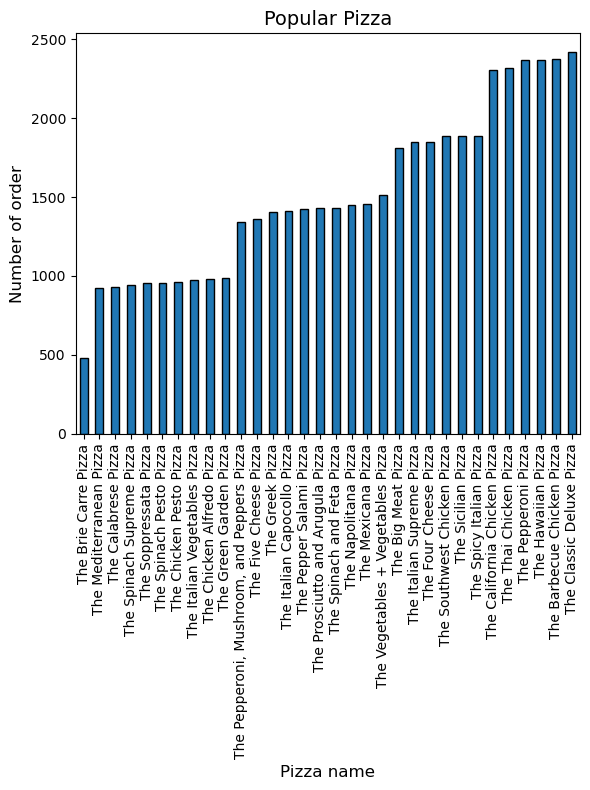

In [29]:
plt.figure(figsize=(6, 8))
popular_pizza.plot(kind = 'bar', edgecolor='black')

plt.title('Popular Pizza', fontsize=14)
plt.xlabel('Pizza name', fontsize=12)
plt.ylabel('Number of order', fontsize=12)
#plt.xticks(customer_return_freq['year'], rotation=0) # 保持 x 軸標籤⽔平
plt.tight_layout()

plt.show()

In [30]:
# Revenues generated by seller & pizza Type.
Revenues_by_seller = df.groupby(['PersonWhoDelivered'])['total_price'].count()
Revenues_by_seller

PersonWhoDelivered
Charlot     7622
Clara      14339
Pedro       3737
Philip      8581
Thomas     14339
Name: total_price, dtype: int64

In [31]:
# Revenues generated by pizza Type.
Revenues_by_type = df.groupby(['pizza_name'])['total_price'].count().sort_values()
Revenues_by_type

pizza_name
The Brie Carre Pizza                           480
The Mediterranean Pizza                        923
The Calabrese Pizza                            927
The Spinach Supreme Pizza                      940
The Soppressata Pizza                          957
The Spinach Pesto Pizza                        957
The Chicken Pesto Pizza                        961
The Italian Vegetables Pizza                   975
The Chicken Alfredo Pizza                      980
The Green Garden Pizza                         987
The Pepperoni, Mushroom, and Peppers Pizza    1342
The Five Cheese Pizza                         1359
The Greek Pizza                               1406
The Italian Capocollo Pizza                   1414
The Pepper Salami Pizza                       1422
The Prosciutto and Arugula Pizza              1428
The Spinach and Feta Pizza                    1431
The Napolitana Pizza                          1451
The Mexicana Pizza                            1456
The Vegetables + Veg

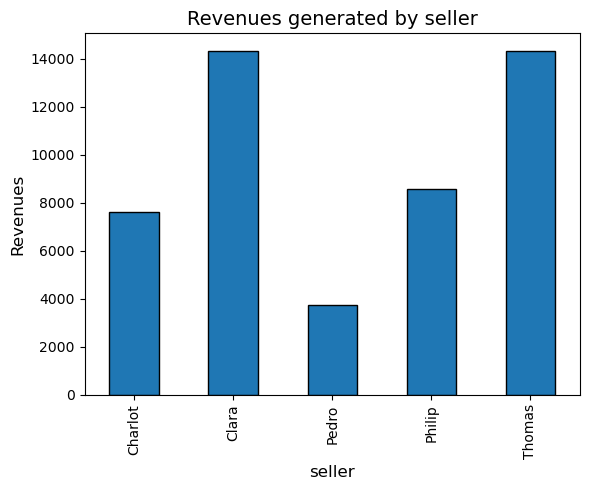

In [32]:
plt.figure(figsize=(6, 5))
Revenues_by_seller.plot(kind = 'bar', edgecolor='black')

plt.title('Revenues generated by seller', fontsize=14)
plt.xlabel('seller', fontsize=12)
plt.ylabel('Revenues', fontsize=12)
#plt.xticks(customer_return_freq['year'], rotation=0) # 保持 x 軸標籤⽔平
plt.tight_layout()

plt.show()

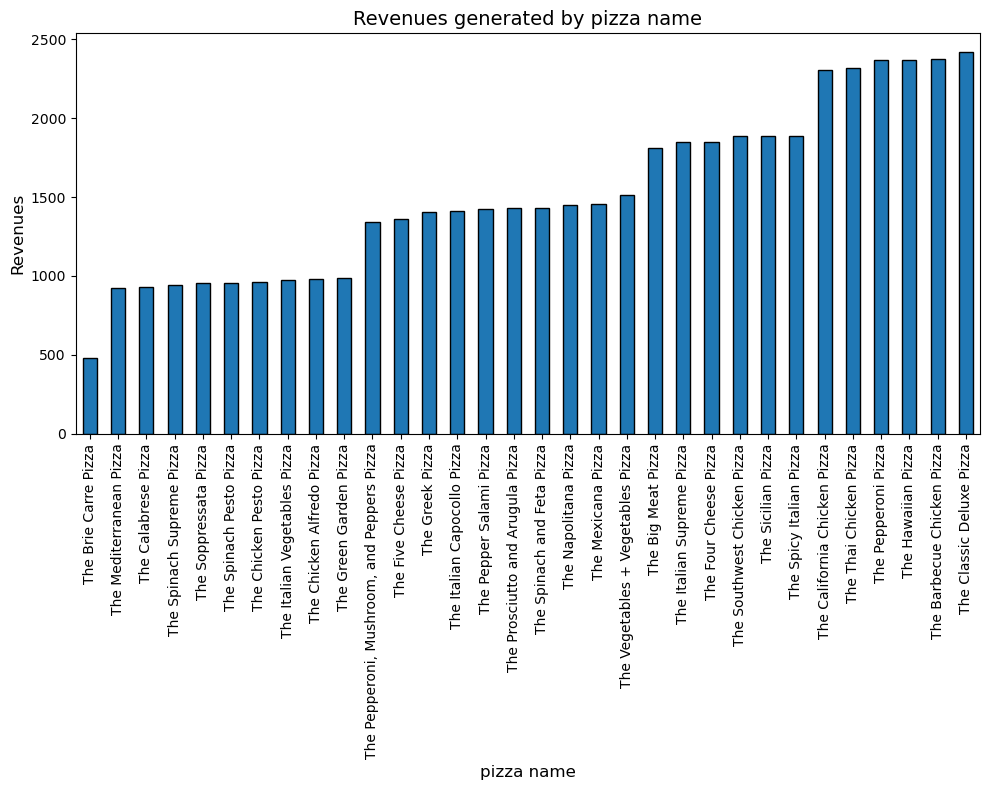

In [33]:
plt.figure(figsize=(10, 8))
Revenues_by_type.plot(kind = 'bar', edgecolor='black')

plt.title('Revenues generated by pizza name', fontsize=14)
plt.xlabel('pizza name', fontsize=12)
plt.ylabel('Revenues', fontsize=12)
#plt.xticks(customer_return_freq['year'], rotation=0) # 保持 x 軸標籤⽔平
plt.tight_layout()

plt.show()

## Step 2: Predictive Analytics

### 2.1 Transforming the Satisfaction Variable

In [66]:
# Transform the Satisfaction_Rate column into a new variable "Satisf-Class" with three classes
def Satisf_Class(Satisfaction_Rate):
    if Satisfaction_Rate < 0.33:
        return 1
    elif 0.33 >= Satisfaction_Rate <= 0.66:
        return 2
    else:
        return 3

df['Satisf_Class'] = df['Satisfaction_Rate'].apply(Satisf_Class)

In [68]:
df

,order_details_id,order_id,pizza_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,...,PersonWhoDelivered,Distance,Housing,GenderOfTipper,Cash_Credit_Tip,Satisfaction_Rate,Recom_Rate,pizza_category_in_numeric,GenderOfTipper_into_numeric,Satisf_Class
0,35497,15674,cali_ckn_l,4,2015-09-19,14:16:35,20.75,83.00,L,Chicken,...,Clara,2.2,Apartment,Female,Cash,0.205884,0.23,1,2,1
1,184,78,spicy_ital_l,3,2015-01-02,12:28:14,20.75,62.25,L,Supreme,...,Philip,1.1,House,Male,Cash,0.254965,0.29,3,1,1
2,18318,8040,thai_ckn_l,3,2015-05-15,14:13:27,20.75,62.25,L,Chicken,...,Pedro,1.9,House,Male,Credit,0.200632,0.24,1,1,1
3,37639,16619,prsc_argla_l,3,2015-10-08,12:19:53,20.75,62.25,L,Supreme,...,Thomas,0.7,House,Male,Cash,0.362180,0.39,3,1,3
4,38820,17112,bbq_ckn_l,3,2015-10-17,12:56:31,20.75,62.25,L,Chicken,...,Thomas,0.4,Hotel,Male,Cash,0.448598,0.52,1,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48615,48369,21242,pepperoni_s,1,2015-12-29,19:54:11,9.75,9.75,S,Classic,...,Philip,0.6,Business,Female,Credit,0.493799,0.51,2,2,3
48616,48375,21244,pepperoni_s,1,2015-12-29,22:10:05,9.75,9.75,S,Classic,...,Clara,2.1,House,Male,Credit,0.497687,0.63,2,1,3
48617,48483,21293,pepperoni_s,1,2015-12-31,14:40:24,9.75,9.75,S,Classic,...,Clara,3.7,House,Female,Credit,0.573152,0.63,2,2,3
48618,48520,21304,pepperoni_s,1,2015-12-31,16:30:41,9.75,9.75,S,Classic,...,Philip,2.0,House,Male,Cash,0.593793,0.63,2,1,3


### 2.2 Predictive Modelling

#### LogisticRegression

In [94]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

X = df[['Recom_Rate','pizza_category_in_numeric', 'GenderOfTipper_into_numeric']]
y = df['Satisf_Class']

# ⽣成⽰例數據
#X, y = make_classification(n_samples=100, n_features=6, n_classes=2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# 建⽴模型
model = LogisticRegression()
model.fit(X_train, y_train)
# 預測
predictions = model.predict(X_test)
# 評估
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy}")
print("Classification Report:")
print(classification_report(y_test, predictions))

Accuracy: 0.9820375702728644
Classification Report:
              precision    recall  f1-score   support

           1       0.97      0.97      0.97      5118
           3       0.99      0.99      0.99      9468

    accuracy                           0.98     14586
   macro avg       0.98      0.98      0.98     14586
weighted avg       0.98      0.98      0.98     14586



In [96]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

X = df[['Recom_Rate','unit_price', 'Distance']]

logistic_regression= LogisticRegression()
logistic_regression.fit(X_train,y_train)
y_pred=LogisticRegression.predict(X_test)

confusion_matrix = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])
sn.heatmap(confusion_matrix, annot=True)

TypeError: LinearClassifierMixin.predict() missing 1 required positional argument: 'X'

#### Random Forest

In [77]:
# Random Forest
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

In [99]:
# Feature selection
X = df[['Recom_Rate','pizza_category_in_numeric', 'GenderOfTipper_into_numeric']]
y = df['Satisf_Class']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model training
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("AUC-ROC:", roc_auc_score(y_test, y_pred_proba))

Accuracy: 0.9795351707116413
Classification Report:
               precision    recall  f1-score   support

           1       0.98      0.96      0.97      3401
           3       0.98      0.99      0.98      6323

    accuracy                           0.98      9724
   macro avg       0.98      0.97      0.98      9724
weighted avg       0.98      0.98      0.98      9724

AUC-ROC: 0.9988310133640257


<Axes: xlabel='Predicted', ylabel='Actual'>

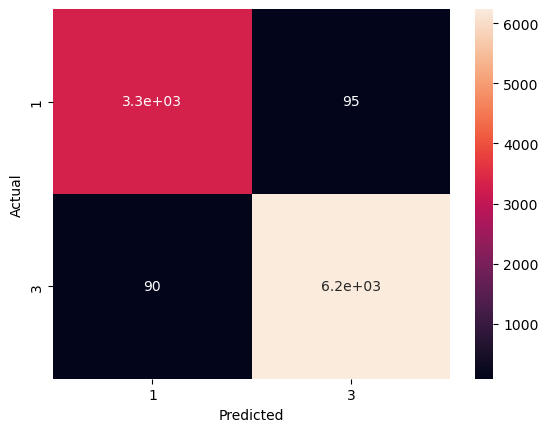

In [160]:
import seaborn as sn
confusion_matrix = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])
sn.heatmap(confusion_matrix, annot=True)
#confusion_matrix

#### LinearRegression

In [156]:
from sklearn.linear_model import LinearRegression
import sklearn
from sklearn import linear_model
import statsmodels.api as sm

X = df[['Recom_Rate','total_price']]
y = df['Satisf_Class']
 
# with sklearn
regr = linear_model.LinearRegression()
regr.fit(X, y)


print( "*****************************************")

print('Intercept: \n', regr.intercept_)
print('Coefficients: \n', regr.coef_)

print( "*****************************************")

# prediction with sklearn
New_Interest_Rate = 2.75
New_Unemployment_Rate = 5.3

print( "*****************************************")

print ('Predicted CO2: \n', regr.predict([[New_Interest_Rate ,New_Unemployment_Rate]]))

print( "*****************************************")
# with statsmodels

*****************************************
Intercept: 
 0.7256021638411916
Coefficients: 
 [3.15617554e+00 1.24858074e-03]
*****************************************
*****************************************
Predicted CO2: 
 [9.41170238]
*****************************************


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## Step 3: Final Report Analytics

In [127]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt  
import seaborn as sn

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics

import statsmodels.api as sm

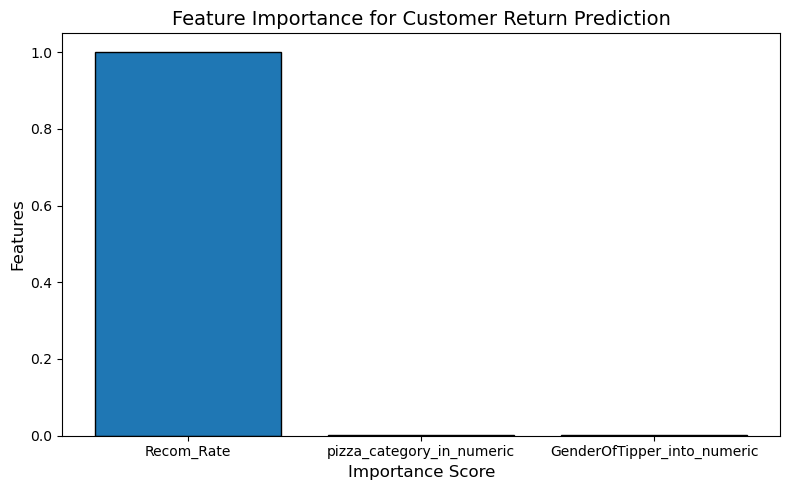

In [114]:
# 特徵重要性
importance = model.feature_importances_
features = ['Recom_Rate','pizza_category_in_numeric', 'GenderOfTipper_into_numeric']
plt.figure(figsize=(8, 5))
plt.bar(features, importance, edgecolor='black')
plt.title('Feature Importance for Customer Return Prediction', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

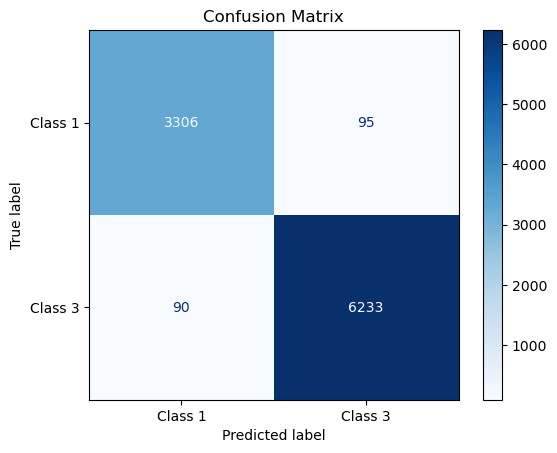

In [116]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
# 計算混淆矩陣
cm = confusion_matrix(y_test, y_pred)
# 視覺化混淆矩陣
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 1', 'Class 3'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()

In [143]:
# Accuracy
print('Accuracy: ',metrics.accuracy_score(y_test, y_pred))

Accuracy:  0.9809749074454956


In [131]:
logistic_regression= LogisticRegression()
logistic_regression.fit(X_train,y_train)
y_pred=logistic_regression.predict(X_test)

#test dataset (without the actual outcome)
print(X_test) 

print("************************************************")

#predicted values
print (y_pred) 

       Recom_Rate  pizza_category_in_numeric  GenderOfTipper_into_numeric
3017     0.620000                          3                            1
12672    0.370000                          4                            1
23608    0.840000                          3                            1
8248     0.820000                          1                            2
24863    0.440000                          3                            1
...           ...                        ...                          ...
23644    0.180000                          3                            2
2149     0.420066                          3                            2
39849    0.700000                          3                            2
32477    0.620000                          2                            1
34172    0.250000                          2                            1

[9724 rows x 3 columns]
************************************************
[3 1 3 ... 3 3 1]


In [133]:
print("*****************************************************")

#predicted values
print (y_pred) 

*****************************************************
[3 1 3 ... 3 3 1]


In [135]:
# Intercept &  Coefficients:

logistic_regression= LogisticRegression()
logistic_regression.fit(X_train,y_train)
y_pred=logistic_regression.predict(X_test)
print('Intercept: \n', logistic_regression.intercept_)
print('Coefficients: \n', logistic_regression.coef_)

Intercept: 
 [-13.13108372]
Coefficients: 
 [[ 3.52512671e+01 -1.99360032e-02 -5.14830413e-02]]


In [137]:
#  logit model summary via  statsmodels.api 
X= sm.add_constant(X)
logit_model = sm.Logit(y, X).fit()
print (logit_model.summary())

ValueError: endog must be in the unit interval.

In [139]:
df['Satisf_Class']

0        1
1        1
2        1
3        3
4        3
        ..
48615    3
48616    3
48617    3
48618    3
48619    3
Name: Satisf_Class, Length: 48618, dtype: int64

In [147]:
X = sm.add_constant(X) # adding a constant
 
model = sm.OLS(y, X).fit()
predictions = model.predict(X) 
 
print_model = model.summary()
print(print_model)

                            OLS Regression Results                            
Dep. Variable:           Satisf_Class   R-squared:                       0.734
Model:                            OLS   Adj. R-squared:                  0.734
Method:                 Least Squares   F-statistic:                 4.479e+04
Date:                Tue, 03 Dec 2024   Prob (F-statistic):               0.00
Time:                        11:34:08   Log-Likelihood:                -34579.
No. Observations:               48618   AIC:                         6.917e+04
Df Residuals:                   48614   BIC:                         6.920e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             